In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("global air pollution dataset.csv")

In [4]:
df.head(5)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [5]:
df.tail(5)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate
23462,Malaysia,Marang,70,Moderate,1,Good,38,Good,0,Good,70,Moderate


In [6]:
mean = df["PM2.5 AQI Value"].mean()
std = df["PM2.5 AQI Value"].std()

print("Mean:", mean)
print("Standard Deviation:", std)

Mean: 68.51975450709628
Standard Deviation: 54.79644316021084


In [7]:
lower_limit_3sigma = mean - 3 * std
upper_limit_3sigma = mean + 3 * std

print("Lower Limit:", lower_limit_3sigma)
print("Upper Limit:", upper_limit_3sigma)

Lower Limit: -95.86957497353623
Upper Limit: 232.9090839877288


In [17]:
X = df_3sigma[['PM2.5 AQI Value']]
y = df_3sigma['AQI Value']

In [16]:
df_3sigma = df[
    (df["PM2.5 AQI Value"] >= lower_limit_3sigma) &
    (df["PM2.5 AQI Value"] <= upper_limit_3sigma)
].copy()

print("Original shape:", df.shape)
print("New shape:", df_3sigma.shape)
print("Rows removed:", len(df) - len(df_3sigma))

Original shape: (23463, 12)
New shape: (23175, 12)
Rows removed: 288


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(18540, 1)
(4635, 1)
(18540,)
(4635,)


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [21]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.9629218532279575
Intercept: 5.60883346987422


In [23]:
y_pred = model.predict(X_test)

In [24]:
print(y_pred[:5])

[ 47.97739501  18.12681756  48.94031687  23.90434868 228.04378157]


In [25]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual   Predicted
0      44   47.977395
1      28   18.126818
2      45   48.940317
3      19   23.904349
4     231  228.043782
5      32   36.422333
6      60   63.384145
7      64   67.235832
8     160  159.676330
9      68   71.087519


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.838810893269928
MSE: 73.31047510328041
RMSE: 8.56215364866109
R² Score: 0.9599028710201719


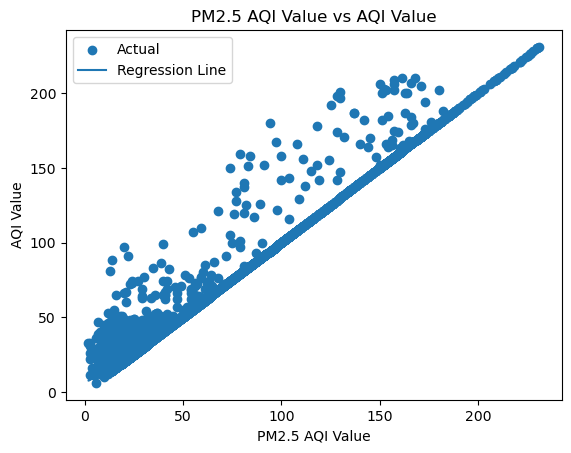

In [27]:
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Regression Line")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("AQI Value")
plt.title("PM2.5 AQI Value vs AQI Value")
plt.legend()
plt.show()